In [3]:
from common.paths import get_sber_gitignore_data_dpath, get_sber_data_dpath
from common.logger import JUPYTER_LOGGER as logger

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from rapidfuzz import fuzz
import wordcloud
import re
import nltk
from nltk.corpus import stopwords

In [5]:
features_dpath = get_sber_gitignore_data_dpath() / "output"
features_fpaths: list = sorted(features_dpath.glob("*.csv"))
all_features = []
for fpath in features_fpaths:
    df = pd.read_csv(fpath)
    all_features.append(df)
features_df = pd.concat(all_features, ignore_index=True)
features_df = features_df.dropna(subset=["query", "ground_truth"])
features_df = features_df.drop_duplicates(subset=["query"])
logger.info(f"Размер итогового датафрейма признаков: {features_df.shape}")

2026-03-31 13:28:05,610 - jupyter-notebooks - INFO - [JUPYTER 📓] Размер итогового датафрейма признаков: (462, 1620)


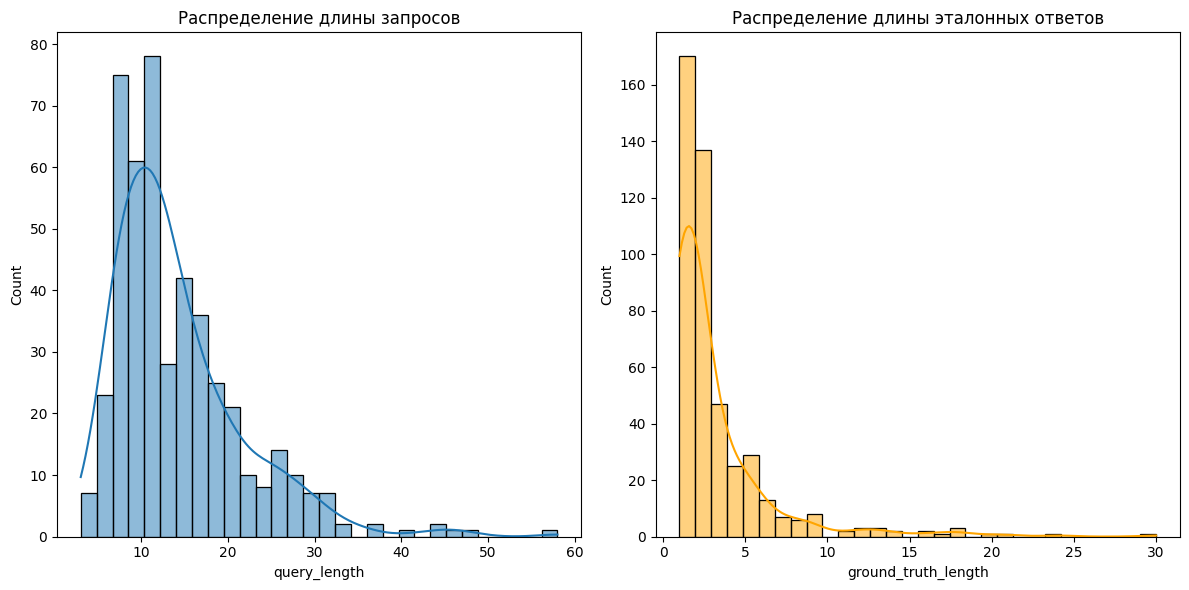

In [7]:
text_df = features_df[["query", "ground_truth", "model_answer"]].copy()
text_df["query_length"] = text_df["query"].apply(lambda x: len(str(x).split()))
text_df["ground_truth_length"] = text_df["ground_truth"].apply(lambda x: len(str(x).split()))
text_df["model_answer_length"] = text_df["model_answer"].apply(lambda x: len(str(x).split()))
text_df["fuzz_partial_ratio"] = text_df.apply(lambda row: fuzz.partial_ratio(str(row["ground_truth"]), str(row["model_answer"])), axis=1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(text_df["query_length"], bins=30, kde=True)
plt.title("Распределение длины запросов")
plt.subplot(1, 2, 2)
sns.histplot(text_df["ground_truth_length"], bins=30, kde=True, color="orange")
plt.title("Распределение длины эталонных ответов")
plt.tight_layout()
plt.show()

In [8]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    tokens = text.split()
    stop_words = set(stopwords.words('russian'))
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

text_df["cleaned_query"] = text_df["query"].apply(preprocess_text)
text_df["cleaned_ground_truth"] = text_df["ground_truth"].apply(preprocess_text)
text_df["cleaned_model_answer"] = text_df["model_answer"].apply(preprocess_text)

C:\Users\User\AppData\Local\Temp\ipykernel_17452\1334596425.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=query_most_common_words.values, y=query_most_common_words.index, palette="Blues_d")
C:\Users\User\AppData\Local\Temp\ipykernel_17452\1334596425.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ground_truth_most_common_words.values, y=ground_truth_most_common_words.index, palette="Oranges_d")
C:\Users\User\AppData\Local\Temp\ipykernel_17452\1334596425.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_answer_most_c

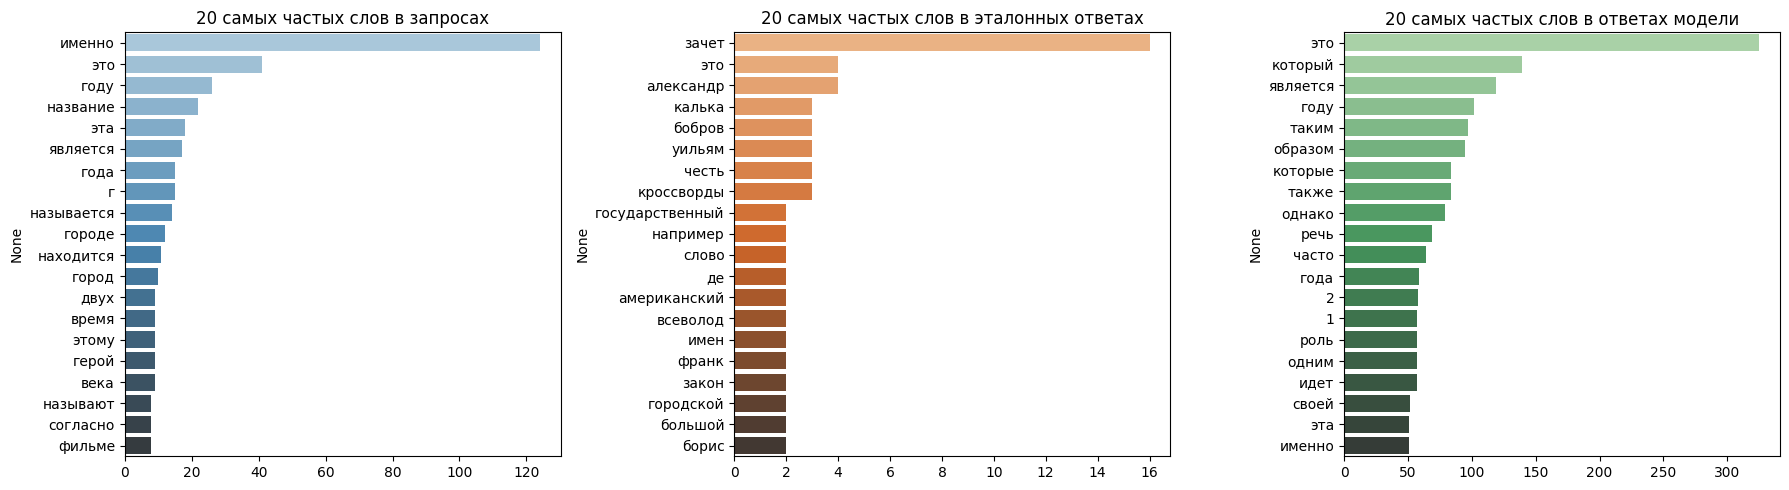

In [9]:
query_most_common_words = text_df["cleaned_query"].str.split(expand=True).stack().value_counts().head(20)
ground_truth_most_common_words = text_df["cleaned_ground_truth"].str.split(expand=True).stack().value_counts().head(20)
model_answer_most_common_words = text_df["cleaned_model_answer"].str.split(expand=True).stack().value_counts().head(20)

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.barplot(x=query_most_common_words.values, y=query_most_common_words.index, palette="Blues_d")
plt.title("20 самых частых слов в запросах")
plt.subplot(1, 3, 2)
sns.barplot(x=ground_truth_most_common_words.values, y=ground_truth_most_common_words.index, palette="Oranges_d")
plt.title("20 самых частых слов в эталонных ответах")
plt.subplot(1, 3, 3)
sns.barplot(x=model_answer_most_common_words.values, y=model_answer_most_common_words.index, palette="Greens_d")
plt.title("20 самых частых слов в ответах модели")
plt.tight_layout()
plt.show()

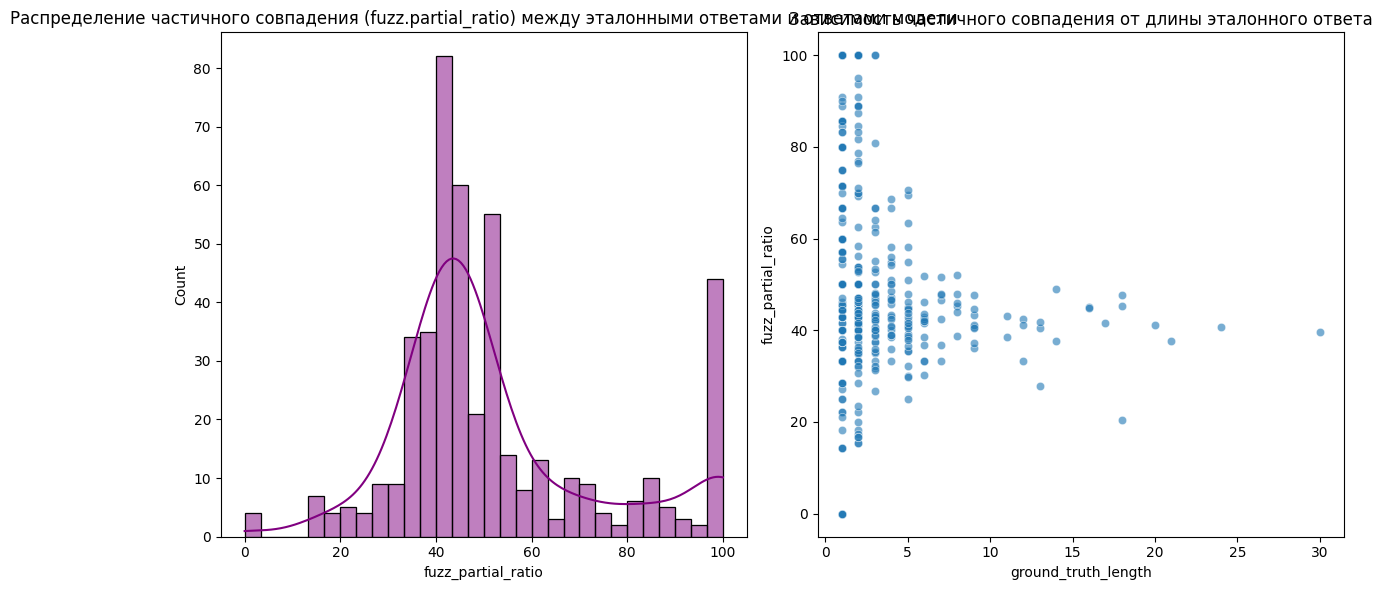

In [10]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(text_df["fuzz_partial_ratio"], bins=30, kde=True, color="purple")
plt.title("Распределение частичного совпадения (fuzz.partial_ratio) между эталонными ответами и ответами модели")
plt.subplot(1, 2, 2)
sns.scatterplot(x="ground_truth_length", y="fuzz_partial_ratio", data=text_df, alpha=0.6)
plt.title("Зависимость частичного совпадения от длины эталонного ответа")
plt.tight_layout()
plt.show()

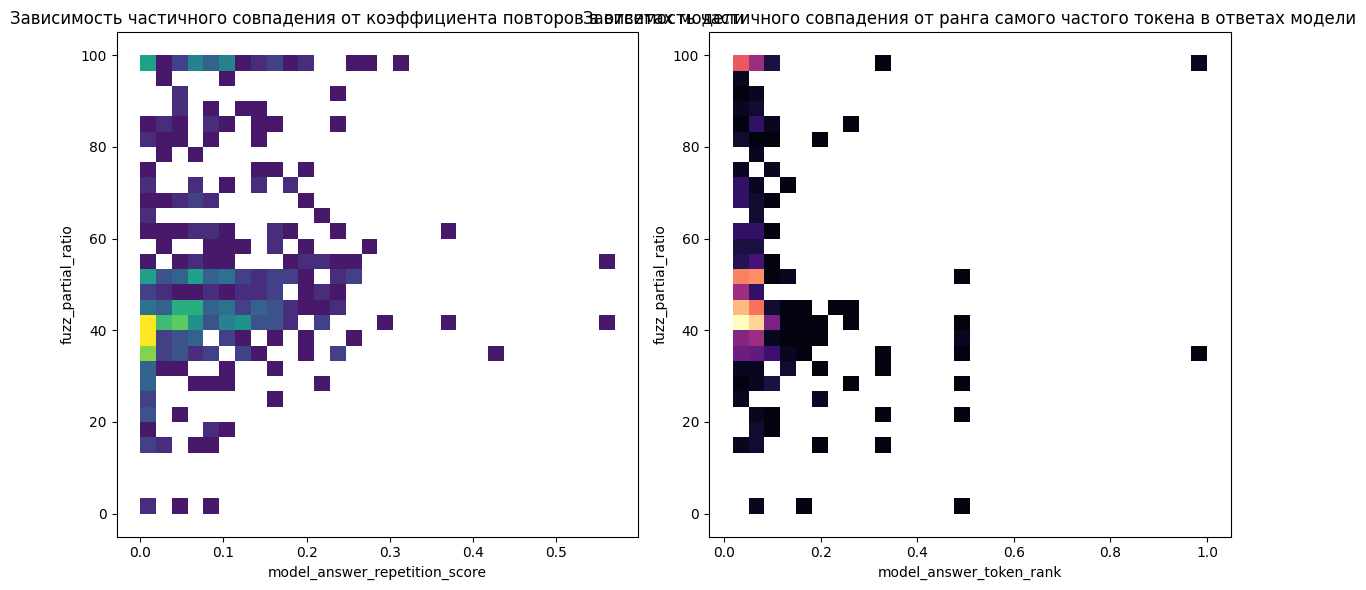

In [12]:
# repetition score
def repetition_score(text):
    tokens = text.split()
    if len(tokens) == 0:
        return 0.0
    unique_tokens = set(tokens)
    return 1 - len(unique_tokens) / len(tokens)

# token rank
def token_rank(text):
    tokens = text.split()
    if len(tokens) == 0:
        return 0.0
    token_counts = pd.Series(tokens).value_counts()
    most_common_count = token_counts.iloc[0]
    return most_common_count / len(tokens)

text_df["model_answer_repetition_score"] = text_df["model_answer"].apply(repetition_score)
text_df["model_answer_token_rank"] = text_df["model_answer"].apply(token_rank)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(x="model_answer_repetition_score", y="fuzz_partial_ratio", data=text_df, bins=30, cmap="viridis")
plt.title("Зависимость частичного совпадения от коэффициента повторов в ответах модели")
plt.subplot(1, 2, 2)
sns.histplot(x="model_answer_token_rank", y="fuzz_partial_ratio", data=text_df, bins=30, cmap="magma")
plt.title("Зависимость частичного совпадения от ранга самого частого токена в ответах модели")
plt.tight_layout()
plt.show()